<a href="https://www.kaggle.com/code/lukaspanos/mall-customers-k-means?scriptVersionId=344988287" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

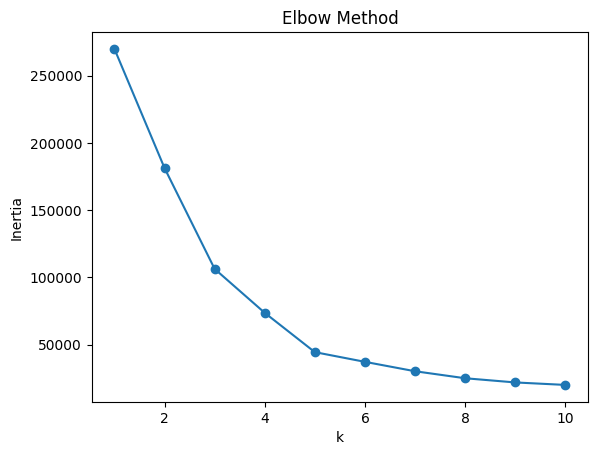

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/kaggle/input/datasets/lukaspanos/mall-customers/Mall_Customers.csv')

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.show()

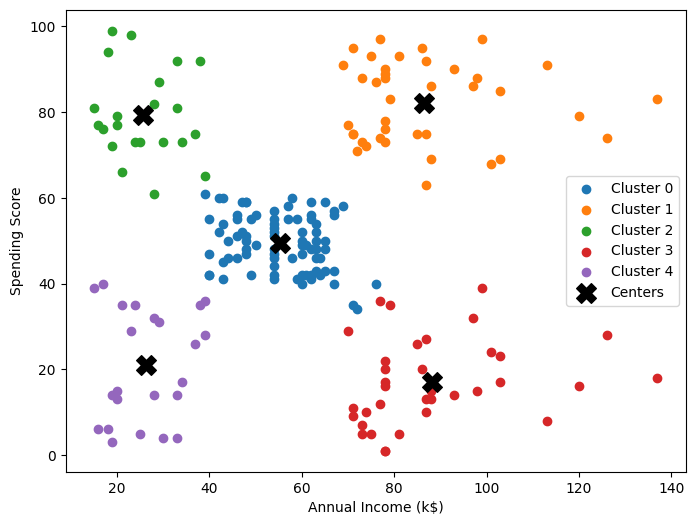

In [2]:
k = 5   # 5 is what the elbow plot suggests, it's the sweet spot. 6 would split the affluent spenders into two groups, which wouldn't be beneficient when doing segmentation
km = KMeans(n_clusters=k, n_init=10, random_state=42)
df['Cluster'] = km.fit_predict(X)

plt.figure(figsize=(8, 6))
for c in range(k):
    sub = df[df['Cluster'] == c]
    plt.scatter(sub['Annual Income (k$)'], sub['Spending Score (1-100)'], label=f'Cluster {c}')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centers')
plt.xlabel('Annual Income (k$)'); plt.ylabel('Spending Score')
plt.legend(); plt.show()